<a href="https://colab.research.google.com/github/ansaganakhat/project-1/blob/main/13_%D0%A2%D0%B0%D0%BF%D1%81%D1%8B%D1%80%D0%BC%D0%B0%D0%BB%D0%B0%D1%80.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Нейрондық желілер негіздері, Тәжірибелік тапсырмалар

**Нұсқаулық:**
Бұл дәптерде 20 тапсырма бар. Әр тапсырмада `# TODO` деп белгіленген жерлерді толтыру керек. Дайын код үлгілері мен нұсқаулар берілген — оларды оқып, бос орындарды өз кодыңызбен толтырыңыз.

**Деңгейлер:**
- Тапсырма 1–7: Негізгі деңгей
- Тапсырма 8–14: Орта деңгей
- Тапсырма 15–20: Жоғары деңгей


In [1]:
# Барлық тапсырмаларға қажетті кітапханалар
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.datasets import make_moons, make_circles, load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix
import tensorflow as tf
from tensorflow import keras
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)
print('Кітапханалар жүктелді.')

Кітапханалар жүктелді.



## Тапсырма 1. Нейронның алға таралуын қолмен есептеу

Бір нейронның есептеуін аяқтаңыз.
Формула: $z = w_1 x_1 + w_2 x_2 + w_3 x_3 + b$, шығыс: $\hat{y} = 1$ егер $z \geq 0$, әйтпесе $0$.

In [ ]:
# Берілген мәндер
x = np.array([1.5, -0.5, 2.0])
w = np.array([0.4, -0.3, 0.1])
b = 0.2

# TODO: z-ны есептеңіз (салмақтар мен кірістің скалярлық көбейтіндісі + бейімділік)
z = # TODO

# TODO: табалдырық функциясын қолданыңыз (z >= 0 болса 1, болмаса 0)
y_hat = # TODO

print(f'z = {z:.4f}')
print(f'y_hat = {y_hat}')

# Тексеру
assert abs(z - 0.85) < 1e-9, 'z дұрыс емес!'
assert y_hat == 1, 'y_hat дұрыс емес!'
print('Тапсырма 1 — ДҰРЫС!')


## Тапсырма 2. Активация функцияларын іске асыру

Төрт активация функциясын өз бетіңізше жазыңыз.

In [ ]:
def my_sigmoid(z):
    # TODO: sigmoid формуласын жазыңыз: 1 / (1 + e^(-z))
    return # TODO

def my_tanh(z):
    # TODO: tanh формуласын жазыңыз (numpy-дің np.tanh қолданбай,
    # (e^z - e^(-z)) / (e^z + e^(-z)) формуласымен жазыңыз)
    return # TODO

def my_relu(z):
    # TODO: ReLU: max(0, z)
    return # TODO

def my_leaky_relu(z, alpha=0.01):
    # TODO: Leaky ReLU: z > 0 болса z, болмаса alpha * z
    return # TODO

# Тексеру
z_test = np.array([-2.0, 0.0, 2.0])
print('Sigmoid:', my_sigmoid(z_test).round(4))
print('Tanh:   ', my_tanh(z_test).round(4))
print('ReLU:   ', my_relu(z_test))
print('L-ReLU: ', my_leaky_relu(z_test))

assert np.allclose(my_sigmoid(z_test), [0.1192, 0.5, 0.8808], atol=1e-3)
assert np.allclose(my_tanh(z_test), np.tanh(z_test), atol=1e-9)
assert np.allclose(my_relu(z_test), [0, 0, 2])
print('Тапсырма 2 — ДҰРЫС!')


## Тапсырма 3. Softmax функциясын жазу

Softmax барлық мәндердің қосындысын 1-ге тең ықтималдыққа айналдырады.
Формула: $\text{softmax}(z_i) = \frac{e^{z_i}}{\sum_j e^{z_j}}$

In [ ]:
def my_softmax(z):
    # TODO: softmax функциясын жазыңыз
    # Кеңес: алдымен np.exp(z) есептеңіз, содан кейін қосындысына бөліңіз
    # Сандық тұрақтылық үшін: exp(z - max(z)) қолданыңыз
    exp_z = # TODO
    return # TODO

logits = np.array([2.0, 1.0, 0.5, 3.0])
probs = my_softmax(logits)

print('Logits:', logits)
print('Ықтималдықтар:', probs.round(4))
print('Қосындысы:', probs.sum().round(6))
print('Болжалды класс:', np.argmax(probs))

assert abs(probs.sum() - 1.0) < 1e-9, 'Қосынды 1 болуы тиіс!'
assert np.argmax(probs) == 3, 'Максималды класс қате!'
print('Тапсырма 3 — ДҰРЫС!')


## Тапсырма 4. Жоғалту функцияларын іске асыру

MSE және Binary Cross-Entropy жоғалту функцияларын жазыңыз.

In [ ]:
y_true = np.array([1, 0, 1, 1, 0, 1])
y_pred = np.array([0.9, 0.2, 0.8, 0.4, 0.3, 0.7])

def mse(y_true, y_pred):
    # TODO: MSE формуласы: орташа (y_true - y_pred)^2
    return # TODO

def binary_cross_entropy(y_true, y_pred, eps=1e-15):
    # TODO: BCE формуласы
    # Кеңес: алдымен y_pred-ті eps пен (1-eps) арасына clip жасаңыз
    # Содан: -mean(y_true * log(y_pred) + (1 - y_true) * log(1 - y_pred))
    y_pred_clipped = # TODO
    return # TODO

mse_val = mse(y_true, y_pred)
bce_val = binary_cross_entropy(y_true, y_pred)

print(f'MSE жоғалтуы: {mse_val:.6f}')
print(f'BCE жоғалтуы: {bce_val:.6f}')

assert abs(mse_val - 0.085) < 1e-3
assert abs(bce_val - 0.3226) < 1e-3
print('Тапсырма 4 — ДҰРЫС!')


## Тапсырма 5. Персептрон класын толтыру

`predict` және `fit` әдістерін толтырып, AND операциясын оқытыңыз.

In [ ]:
class MyPerceptron:
    def __init__(self, lr=0.1, epochs=100):
        self.lr = lr
        self.epochs = epochs
        self.w = None
        self.b = None

    def predict(self, X):
        # TODO: z = X @ self.w + self.b есептеңіз
        # TODO: z >= 0 болса 1, болмаса 0 қайтарыңыз
        z = # TODO
        return # TODO

    def fit(self, X, y):
        n_samples, n_features = X.shape
        # TODO: self.w нөлдерден тұратын n_features өлшемді вектор
        self.w = # TODO
        # TODO: self.b = 0
        self.b = # TODO

        for _ in range(self.epochs):
            for xi, yi in zip(X, y):
                y_hat = self.predict(xi.reshape(1, -1))[0]
                error = yi - y_hat
                # TODO: салмақтарды жаңартыңыз: w += lr * error * xi
                self.w += # TODO
                # TODO: бейімділікті жаңартыңыз: b += lr * error
                self.b += # TODO

# AND деректері
X_and = np.array([[0,0],[0,1],[1,0],[1,1]])
y_and = np.array([0, 0, 0, 1])

p = MyPerceptron(lr=0.1, epochs=50)
p.fit(X_and, y_and)
preds = p.predict(X_and)

print('AND нәтижелері:')
for xi, yi, pi in zip(X_and, y_and, preds):
    print(f'  {xi} -> нақты: {yi}, болжам: {pi}')

assert np.array_equal(preds, y_and), 'AND дұрыс жіктелмеді!'
print('Тапсырма 5 — ДҰРЫС!')


## Тапсырма 6. Персептронның шектеуін дәлелдеу

XOR деректерінде персептронды оқытып, дәлдігін есептеңіз. Неге дәлдік 50–75% аспайтынын түсіндіріңіз.

In [ ]:
X_xor = np.array([[0,0],[0,1],[1,0],[1,1]])
y_xor = np.array([0, 1, 1, 0])

# TODO: MyPerceptron класын XOR деректерінде оқытыңыз (epochs=1000)
p_xor = # TODO
# TODO: fit қолданыңыз
# TODO

# TODO: болжам жасаңыз
preds_xor = # TODO

# TODO: дәлдікті есептеңіз (дұрыс болжамдар санын жалпы санға бөліңіз)
accuracy = # TODO

print(f'XOR нәтижелері: {preds_xor}')
print(f'Нақты белгілер: {y_xor}')
print(f'Дәлдік: {accuracy:.2%}')
print()

# TODO: Нәтижені өз сөзіңізбен түсіндіріңіз (print арқылы)
# Неге персептрон XOR-ды шеше алмайды?
print('Түсіндірме:')
print('# TODO: өз жауабыңызды жазыңыз')


## Тапсырма 7. Параметрлер санын есептеу

Берілген архитектуралар үшін барлық параметрлер санын есептейтін функция жазыңыз.

In [ ]:
def count_params(architecture):
    """
    architecture: қабаттардағы нейрондар тізімі, мысалы [784, 128, 64, 10]
    Қайтарады: жалпы параметрлер саны (салмақтар + бейімділіктер)
    """
    total = 0
    for i in range(1, len(architecture)):
        n_in = architecture[i - 1]
        n_out = architecture[i]
        # TODO: бұл қабаттың салмақтар санын есептеңіз
        weights = # TODO
        # TODO: бейімділіктер санын есептеңіз
        biases = # TODO
        total += weights + biases
    return total

# Тексеру
arch1 = [2, 4, 1]
arch2 = [784, 128, 64, 10]
arch3 = [3, 5, 5, 3, 1]

p1 = count_params(arch1)
p2 = count_params(arch2)
p3 = count_params(arch3)

print(f'[2,4,1]        -> {p1} параметр (күтілетін: 17)')
print(f'[784,128,64,10]-> {p2} параметр (күтілетін: 109386)')
print(f'[3,5,5,3,1]    -> {p3} параметр (күтілетін: 69)')

assert p1 == 17
assert p2 == 109386
assert p3 == 69
print('Тапсырма 7 — ДҰРЫС!')


## Тапсырма 8. Тура таралуды матрицалық форматта жазу

Екі қабатты желінің тура таралуын матрицалық операциялармен іске асырыңыз.

In [ ]:
np.random.seed(7)

# Берілген параметрлер (4 мысал, 3 белгі)
X = np.array([[0.5, 1.2, -0.3],
              [1.0, -0.5, 0.8],
              [0.2, 0.9,  1.1],
              [-0.4, 0.3, 0.7]])  # 4 x 3

W1 = np.random.randn(5, 3) * 0.1   # 5 x 3
b1 = np.zeros((1, 5))               # 1 x 5
W2 = np.random.randn(2, 5) * 0.1   # 2 x 5
b2 = np.zeros((1, 2))               # 1 x 2

def relu(z):
    return np.maximum(0, z)

def softmax_rows(Z):
    """Әр жол үшін softmax."""
    exp_Z = np.exp(Z - Z.max(axis=1, keepdims=True))
    return exp_Z / exp_Z.sum(axis=1, keepdims=True)

# TODO: 1-қабатты есептеңіз
# Z1 = X @ W1.T + b1  (өлшемі: 4 x 5)
Z1 = # TODO
# TODO: ReLU активациясы
A1 = # TODO

# TODO: 2-қабатты есептеңіз
# Z2 = A1 @ W2.T + b2  (өлшемі: 4 x 2)
Z2 = # TODO
# TODO: Softmax активациясы
A2 = # TODO

print(f'X өлшемі:  {X.shape}')
print(f'Z1 өлшемі: {Z1.shape}  (күтілетін: (4, 5))')
print(f'A1 өлшемі: {A1.shape}  (күтілетін: (4, 5))')
print(f'Z2 өлшемі: {Z2.shape}  (күтілетін: (4, 2))')
print(f'A2 өлшемі: {A2.shape}  (күтілетін: (4, 2))')
print(f'\nSoftmax шығысы (ықтималдықтар):\n{A2.round(4)}')
print(f'Қосындылар: {A2.sum(axis=1).round(6)}  (барлығы 1 болуы тиіс)')

assert Z1.shape == (4, 5)
assert A2.shape == (4, 2)
assert np.allclose(A2.sum(axis=1), 1.0)
print('Тапсырма 8 — ДҰРЫС!')


## Тапсырма 9. Градиенттік түсуді іске асыру

Бір параметрлі $L(w) = (w - 3)^2$ функциясы үшін градиенттік түсуді жазыңыз.

In [ ]:
def loss_fn(w):
    return (w - 3.0) ** 2

def loss_gradient(w):
    # TODO: L(w) = (w-3)^2 функциясының туындысы: dL/dw = ?
    return # TODO

def gradient_descent(w_init, lr, n_steps):
    w = w_init
    history = {'w': [w], 'loss': [loss_fn(w)]}

    for step in range(n_steps):
        grad = loss_gradient(w)
        # TODO: w-ны градиент бойынша жаңартыңыз
        w = # TODO
        history['w'].append(w)
        history['loss'].append(loss_fn(w))

    return w, history

w_final, hist = gradient_descent(w_init=10.0, lr=0.1, n_steps=50)

print(f'Бастапқы w: 10.0,  Жоғалту: {hist["loss"][0]:.4f}')
print(f'Соңғы w:    {w_final:.6f},  Жоғалту: {hist["loss"][-1]:.8f}')
print(f'Теориялық минимум: w = 3.0')

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
# TODO: эпоха бойынша жоғалту қисығын сызыңыз
plt.plot(# TODO, label='Жоғалту')
plt.xlabel('Итерация'); plt.ylabel('L(w)'); plt.title('Жоғалту')
plt.grid(True, alpha=0.3); plt.legend()

plt.subplot(1, 2, 2)
# TODO: w мәнінің өзгерісін сызыңыз
plt.plot(# TODO, color='orange', label='w мәні')
plt.axhline(y=3.0, color='red', linestyle='--', label='Минимум (w=3)')
plt.xlabel('Итерация'); plt.ylabel('w'); plt.title('w эволюциясы')
plt.grid(True, alpha=0.3); plt.legend()
plt.tight_layout(); plt.show()

assert abs(w_final - 3.0) < 0.01, 'Минимумға жете алмады!'
print('Тапсырма 9 — ДҰРЫС!')


## Тапсырма 10. Кері таралудың бір қадамын есептеу

Бір жасырын қабатты желі үшін кері таралудың барлық градиенттерін есептеңіз.

In [ ]:
np.random.seed(1)
X_b = np.array([[0.6], [-0.4]])   # 2x1
y_b = np.array([[1.0]])            # 1x1

W1_b = np.array([[ 0.1, -0.2],
                  [ 0.3,  0.4],
                  [-0.1,  0.2]])
b1_b = np.zeros((3, 1))
W2_b = np.array([[0.5, -0.3, 0.2]])
b2_b = np.zeros((1, 1))

def sig(z): return 1/(1+np.exp(-z))
def relu_deriv(z): return (z>0).astype(float)

# === ТУРА ТАРАЛУ ===
Z1_b = W1_b @ X_b + b1_b
A1_b = relu(Z1_b)
Z2_b = W2_b @ A1_b + b2_b
A2_b = sig(Z2_b)

eps = 1e-15
A2c = np.clip(A2_b, eps, 1-eps)
loss = float(-y_b * np.log(A2c) - (1-y_b) * np.log(1-A2c))

# === КЕРІ ТАРАЛУ ===
# Шығыс қабат: Sigmoid + BCE комбинациясы → delta2 = A2 - y
delta2 = A2_b - y_b
dW2 = delta2 @ A1_b.T
db2 = delta2

# Жасырын қабатқа таралу (тізбекті ереже)
da1 = W2_b.T @ delta2
delta1 = da1 * relu_deriv(Z1_b)   # ReLU туындысы
dW1 = delta1 @ X_b.T
db1 = delta1

print('=== ТУРА ТАРАЛУ ===')
print(f'Z1 = W1@X + b1 = {Z1_b.T}')
print(f'A1 = ReLU(Z1)  = {A1_b.T}')
print(f'Z2 = W2@A1+b2  = {Z2_b[0,0]:.6f}')
print(f'A2 = sigmoid   = {A2_b[0,0]:.6f}  (болжам)')
print(f'BCE жоғалту    = {loss:.6f}')

print('\n=== КЕРІ ТАРАЛУ ===')
print(f'δ[2] = A2 - y  = {delta2[0,0]:.6f}')
print(f'∂L/∂W2         = {dW2}')
print(f'∂L/∂b2         = {db2[0,0]:.6f}')
print(f'da1            = {da1.T}')
print(f'ReLU туынды    = {relu_deriv(Z1_b).T}')
print(f'δ[1]           = {delta1.T}')
print(f'∂L/∂W1         =\n{dW1}')

# Жаңартылған параметрлер
lr = 0.5
W2_new = W2_b - lr * dW2
W1_new = W1_b - lr * dW1
Z2_check = W2_new @ my_relu(W1_new @ X_b + b1_b - lr*db1) + b2_b - lr*db2
A2_new = sig(Z2_check)
loss_new = float(-y_b*np.log(np.clip(A2_new,eps,1-eps))-(1-y_b)*np.log(np.clip(1-A2_new,eps,1-eps)))
print(f'\n=== БІР ҚАДАМ КЕЙІН ===')
print(f'Жоғалту: {loss:.6f} → {loss_new:.6f} (азайды: {loss > loss_new})')

assert dW2.shape == (1, 3) and dW1.shape == (3, 2)
print('Тапсырма 10 — ДҰРЫС!')

NameError: name 'relu' is not defined


## Тапсырма 11. Оқыту жылдамдығының (lr) әсерін зерттеу

Үш түрлі оқыту жылдамдығын салыстырып, графикте көрсетіңіз.

In [ ]:
X_lr, y_lr = make_moons(n_samples=500, noise=0.2, random_state=42)
X_lr = StandardScaler().fit_transform(X_lr)
X_tr, X_te, y_tr, y_te = train_test_split(X_lr, y_lr, test_size=0.2, random_state=42)

learning_rates = [0.0001, 0.01, 0.5]
colors_lr = ['#E91E63', '#2196F3', '#4CAF50']

plt.figure(figsize=(13, 4))

for lr_val, color in zip(learning_rates, colors_lr):
    tf.random.set_seed(42)
    # TODO: keras.Sequential моделін жасаңыз
    # Архитектура: Input(2) → Dense(16, relu) → Dense(8, relu) → Dense(1, sigmoid)
    model_lr = keras.Sequential([
        # TODO
    ])
    # TODO: моделді compile жасаңыз
    # optimizer=keras.optimizers.SGD(learning_rate=lr_val)
    # loss='binary_crossentropy', metrics=['accuracy']
    model_lr.compile(# TODO)

    # TODO: моделді 80 эпоха оқытыңыз (batch_size=32, verbose=0)
    hist_lr = model_lr.fit(# TODO)

    # TODO: val_loss қисығын сызыңыз
    plt.plot(# TODO, color=color, linewidth=2, label=f'lr={lr_val}')

plt.xlabel('Эпоха', fontsize=12)
plt.ylabel('Валидация жоғалтуы', fontsize=12)
plt.title('Оқыту жылдамдығының әсері', fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# TODO: Нәтижені талдаңыз: қай lr жақсырақ және неге?
print('Талдау:')
print('# TODO: өз жауабыңызды жазыңыз')


## Тапсырма 12. Желі тереңдігінің (қабат санының) дәлдікке әсері

1, 2, 3, 4 жасырын қабатты желілерді салыстырыңыз.

In [ ]:
X_d, y_d = make_circles(n_samples=600, noise=0.1, factor=0.4, random_state=42)
X_d = StandardScaler().fit_transform(X_d)
X_dtr, X_dte, y_dtr, y_dte = train_test_split(X_d, y_d, test_size=0.2, random_state=42)

depths = [1, 2, 3, 4]
results_depth = {}

for depth in depths:
    tf.random.set_seed(42)

    # TODO: depth жасырын қабатты желі жасаңыз
    # Әрбір жасырын қабатта 16 нейрон, relu активациясы
    # Шығыс: 1 нейрон, sigmoid
    layers = [keras.layers.Input(shape=(2,))]
    for _ in range(depth):
        layers.append(# TODO)
    layers.append(# TODO)  # шығыс қабат

    model_d = keras.Sequential(layers)
    # TODO: compile жасаңыз (adam, binary_crossentropy, accuracy)
    model_d.compile(# TODO)
    # TODO: 60 эпоха оқытыңыз (batch_size=32, verbose=0)
    model_d.fit(# TODO)

    # TODO: тест дәлдігін есептеп results_depth[depth] ішіне сақтаңыз
    _, acc = model_d.evaluate(# TODO, verbose=0)
    results_depth[depth] = acc
    print(f'{depth} жасырын қабат: тест дәлдігі = {acc:.4f}')

# TODO: нәтижелерді бар диаграммада (bar chart) көрсетіңіз
plt.figure(figsize=(7, 4))
plt.bar(# TODO)
plt.xlabel('Жасырын қабаттар саны', fontsize=12)
plt.ylabel('Тест дәлдігі', fontsize=12)
plt.title('Желі тереңдігінің дәлдікке әсері', fontsize=13, fontweight='bold')
plt.ylim(0.5, 1.05)
plt.grid(True, alpha=0.3, axis='y')
plt.show()


## Тапсырма 13. Dropout регуляризациясы

Dropout-сыз және Dropout-пен модельдерді салыстырыңыз.

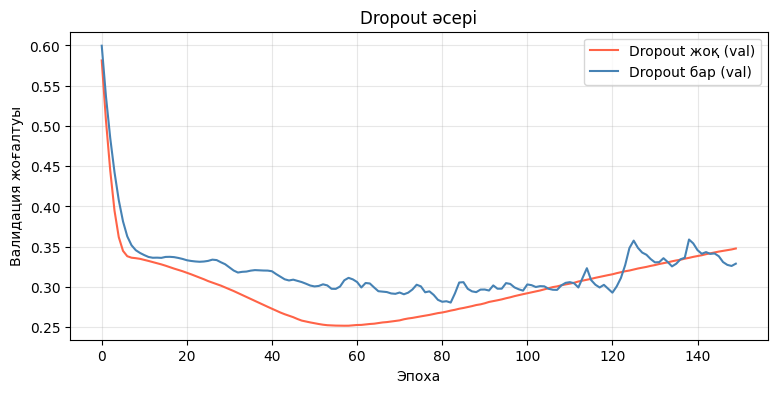

Dropout жоқ — тест дәлдігі: 0.9167
Dropout бар — тест дәлдігі: 0.9000


In [6]:

X_drop, y_drop = make_moons(n_samples=200, noise=0.3, random_state=42)
X_drop = StandardScaler().fit_transform(X_drop)
X_dptr, X_dpte, y_dptr, y_dpte = train_test_split(
    X_drop, y_drop, test_size=0.3, random_state=42
)

tf.random.set_seed(42)

# --------- Dropout жоқ модель ---------
model_no_drop = keras.Sequential([
    keras.layers.Dense(64, activation='relu', input_shape=(2,)),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

model_no_drop.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

hist_no_drop = model_no_drop.fit(
    X_dptr, y_dptr,
    epochs=150,
    batch_size=16,
    validation_data=(X_dpte, y_dpte),
    verbose=0
)

tf.random.set_seed(42)

# --------- Dropout бар модель ---------
model_drop = keras.Sequential([
    keras.layers.Dense(64, activation='relu', input_shape=(2,)),
    keras.layers.Dropout(0.4),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.4),
    keras.layers.Dense(1, activation='sigmoid')
])

model_drop.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

hist_drop = model_drop.fit(
    X_dptr, y_dptr,
    epochs=150,
    batch_size=16,
    validation_data=(X_dpte, y_dpte),
    verbose=0
)


plt.figure(figsize=(9, 4))

plt.plot(hist_no_drop.history['val_loss'],
         label='Dropout жоқ (val)', color='tomato')

plt.plot(hist_drop.history['val_loss'],
         label='Dropout бар (val)', color='steelblue')

plt.xlabel('Эпоха')
plt.ylabel('Валидация жоғалтуы')
plt.title('Dropout әсері')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


_, acc_no = model_no_drop.evaluate(X_dpte, y_dpte, verbose=0)
_, acc_yes = model_drop.evaluate(X_dpte, y_dpte, verbose=0)

print(f'Dropout жоқ — тест дәлдігі: {acc_no:.4f}')
print(f'Dropout бар — тест дәлдігі: {acc_yes:.4f}')


## Тапсырма 14. Batch Normalization-ды қосу

BatchNorm-сыз және BatchNorm-пен модельдердің оқыту жылдамдығын салыстырыңыз.

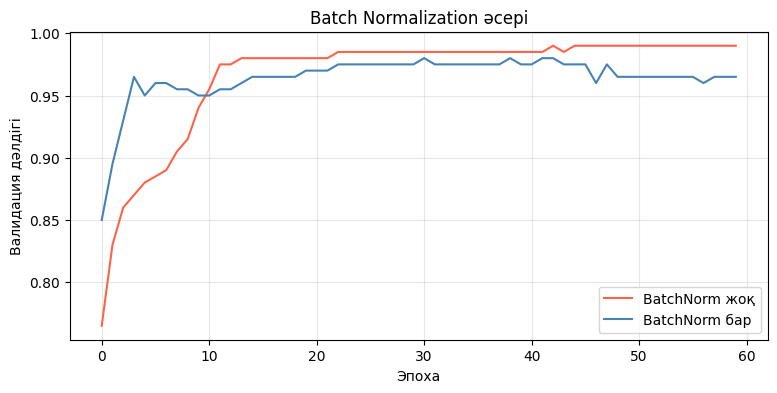

BatchNorm жоқ: 0.9900
BatchNorm бар: 0.9650


In [5]:
from tensorflow.keras.layers import Dense, BatchNormalization, Activation
X_bn, y_bn = make_moons(n_samples=1000, noise=0.2, random_state=42)
X_bn = StandardScaler().fit_transform(X_bn)

X_bntr, X_bnte, y_bntr, y_bnte = train_test_split(
    X_bn, y_bn, test_size=0.2, random_state=42
)

tf.random.set_seed(42)

# --------- BatchNorm жоқ ---------
model_no_bn = keras.Sequential([
    Dense(32, activation='relu', input_shape=(2,)),
    Dense(32, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_no_bn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

hist_no_bn = model_no_bn.fit(
    X_bntr, y_bntr,
    epochs=60,
    batch_size=32,
    validation_data=(X_bnte, y_bnte),
    verbose=0
)

tf.random.set_seed(42)

# --------- BatchNorm бар ---------
model_bn = keras.Sequential([
    Dense(32, input_shape=(2,)),
    BatchNormalization(),
    Activation('relu'),

    Dense(32),
    BatchNormalization(),
    Activation('relu'),

    Dense(32),
    BatchNormalization(),
    Activation('relu'),

    Dense(1, activation='sigmoid')
])

model_bn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

hist_bn = model_bn.fit(
    X_bntr, y_bntr,
    epochs=60,
    batch_size=32,
    validation_data=(X_bnte, y_bnte),
    verbose=0
)


plt.figure(figsize=(9, 4))

plt.plot(hist_no_bn.history['val_accuracy'],
         label='BatchNorm жоқ', color='tomato')

plt.plot(hist_bn.history['val_accuracy'],
         label='BatchNorm бар', color='steelblue')

plt.xlabel('Эпоха')
plt.ylabel('Валидация дәлдігі')
plt.title('Batch Normalization әсері')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


_, acc_no_bn = model_no_bn.evaluate(X_bnte, y_bnte, verbose=0)
_, acc_bn = model_bn.evaluate(X_bnte, y_bnte, verbose=0)

print(f'BatchNorm жоқ: {acc_no_bn:.4f}')
print(f'BatchNorm бар: {acc_bn:.4f}')


## Тапсырма 15. Толық нейрондық желіні нөлден жазу

NumPy ғана пайдаланып, толық MLP классын іске асырыңыз: тура таралу, кері таралу, параметр жаңарту — бәрін өз бетіңізше.

In [ ]:
class NeuralNetworkFromScratch:
    """
    NumPy ғана қолданып жазылған MLP.
    Архитектура: n_input → n_hidden → 1
    Активациялар: ReLU (жасырын), Sigmoid (шығыс)
    Жоғалту: Binary Cross-Entropy
    """

    def __init__(self, n_input, n_hidden, lr=0.01):
        np.random.seed(42)
        # TODO: He инициализациясы: W * sqrt(2/n_input)
        self.W1 = # TODO  # өлшемі: (n_hidden, n_input)
        self.b1 = # TODO  # өлшемі: (n_hidden, 1), нөлдер
        self.W2 = # TODO  # өлшемі: (1, n_hidden)
        self.b2 = # TODO  # өлшемі: (1, 1), нөлдер
        self.lr = lr
        self.loss_log = []

    def _sigmoid(self, z):
        # TODO
        return # TODO

    def _relu(self, z):
        # TODO
        return # TODO

    def forward(self, X):
        # X өлшемі: (n_input, m)  — m мысал
        # TODO: 1-қабат
        self.Z1 = # TODO
        self.A1 = # TODO
        # TODO: 2-қабат
        self.Z2 = # TODO
        self.A2 = # TODO
        return self.A2

    def compute_loss(self, y, eps=1e-15):
        m = y.shape[1]
        A2 = np.clip(self.A2, eps, 1 - eps)
        # TODO: BCE жоғалтуы
        return # TODO

    def backward(self, X, y):
        m = X.shape[1]
        # TODO: шығыс қабат градиенті
        dZ2 = # TODO  # A2 - y
        dW2 = # TODO  # dZ2 @ A1.T / m
        db2 = # TODO  # sum(dZ2) / m
        # TODO: жасырын қабат градиенті
        dA1 = # TODO  # W2.T @ dZ2
        dZ1 = # TODO  # dA1 * relu_deriv(Z1)
        dW1 = # TODO  # dZ1 @ X.T / m
        db1 = # TODO  # sum(dZ1) / m
        # TODO: параметрлерді жаңарту
        self.W2 -= # TODO
        self.b2 -= # TODO
        self.W1 -= # TODO
        self.b1 -= # TODO

    def train(self, X, y, epochs=2000):
        for epoch in range(epochs):
            # TODO: forward, loss, backward кезекпен шақырыңыз
            # TODO
            loss = self.compute_loss(y)
            # TODO
            self.loss_log.append(loss)
            if (epoch + 1) % 500 == 0:
                preds = (self.A2 > 0.5).astype(int)
                acc = np.mean(preds == y) * 100
                print(f'Эпоха {epoch+1:5d} | Жоғалту: {loss:.5f} | Дәлдік: {acc:.1f}%')

    def predict(self, X):
        return (self.forward(X) > 0.5).astype(int)


# Тексеру: XOR есебі
X_xor_t = np.array([[0,0,1,1],[0,1,0,1]], dtype=float)  # 2x4
y_xor_t = np.array([[0,1,1,0]], dtype=float)             # 1x4

nn = NeuralNetworkFromScratch(n_input=2, n_hidden=8, lr=0.5)
nn.train(X_xor_t, y_xor_t, epochs=2000)

final_preds = nn.predict(X_xor_t)
print(f'\nСоңғы болжамдар: {final_preds[0]}')
print(f'Нақты белгілер: {y_xor_t[0].astype(int)}')
acc_xor = np.mean(final_preds == y_xor_t)
print(f'XOR дәлдігі: {acc_xor:.2%}')
assert acc_xor == 1.0, 'XOR 100% дәлдікпен шешілуі тиіс!'
print('Тапсырма 15 — ДҰРЫС!')


## Тапсырма 16. Оңтайландырушыларды салыстыру

SGD, Adam, RMSprop оңтайландырушыларын бір архитектурада сынап, жинақталу жылдамдықтарын салыстырыңыз.

In [ ]:
X_opt, y_opt = make_moons(n_samples=800, noise=0.2, random_state=42)
X_opt = StandardScaler().fit_transform(X_opt)
X_otr, X_ote, y_otr, y_ote = train_test_split(X_opt, y_opt, test_size=0.2, random_state=42)

# TODO: 3 оңтайландырушыны тізімге салыңыз
# Форматы: [('атауы', optimizer_объектісі), ...]
optimizers_list = [
    ('SGD',     # TODO: keras.optimizers.SGD(learning_rate=0.01)
    ),
    ('Adam',    # TODO: keras.optimizers.Adam(learning_rate=0.001)
    ),
    ('RMSprop', # TODO: keras.optimizers.RMSprop(learning_rate=0.001)
    ),
]

colors_opt_list = ['#E91E63', '#2196F3', '#FF9800']
plt.figure(figsize=(13, 4))

for (name, opt_obj), color in zip(optimizers_list, colors_opt_list):
    tf.random.set_seed(42)
    # TODO: бірдей архитектуралы модель жасаңыз
    # Input(2) → Dense(32, relu) → Dense(16, relu) → Dense(1, sigmoid)
    model_opt = keras.Sequential([# TODO])
    # TODO: compile жасаңыз (opt_obj оңтайландырушысымен)
    model_opt.compile(# TODO)
    # TODO: 100 эпоха оқытыңыз
    hist_opt = model_opt.fit(# TODO, verbose=0)

    _, test_acc_opt = model_opt.evaluate(X_ote, y_ote, verbose=0)
    # TODO: val_loss қисығын сызыңыз
    plt.plot(# TODO, color=color, linewidth=2,
             label=f'{name} (acc={test_acc_opt:.3f})')

plt.xlabel('Эпоха', fontsize=12)
plt.ylabel('Валидация жоғалтуы', fontsize=12)
plt.title('Оңтайландырушылар салыстыруы', fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Тапсырма 17. Сандық градиент тексеру (Gradient Checking)

Кері таралу арқылы есептелген градиенттерді сандық жуықтаумен тексеріңіз.

In [ ]:
np.random.seed(0)

# Кішкентай желі: 2 → 3 → 1
Wgc1 = np.random.randn(3, 2) * 0.1
bgc1 = np.zeros((3, 1))
Wgc2 = np.random.randn(1, 3) * 0.1
bgc2 = np.zeros((1, 1))
Xgc = np.random.randn(2, 4)
ygc = np.array([[1, 0, 1, 0]])

def sigmoid(z): return 1 / (1 + np.exp(-z))
def relu(z): return np.maximum(0, z)
def relu_d(z): return (z > 0).astype(float)

def forward_and_loss(W1, b1, W2, b2, X, y, eps=1e-15):
    Z1 = W1 @ X + b1
    A1 = relu(Z1)
    Z2 = W2 @ A1 + b2
    A2 = sigmoid(Z2)
    A2c = np.clip(A2, eps, 1 - eps)
    loss = -np.mean(y * np.log(A2c) + (1 - y) * np.log(1 - A2c))
    return loss, Z1, A1, A2

# Аналитикалық градиенттер (кері таралу)
loss0, Z1gc, A1gc, A2gc = forward_and_loss(Wgc1, bgc1, Wgc2, bgc2, Xgc, ygc)
m = Xgc.shape[1]
dZ2 = (A2gc - ygc) / m
dW2_analytic = dZ2 @ A1gc.T
dA1 = Wgc2.T @ dZ2
dZ1 = dA1 * relu_d(Z1gc)
dW1_analytic = dZ1 @ Xgc.T

eps = 1e-7

def numerical_gradient_W(W, b_fixed, W2_fixed, b2_fixed, which_W):
    """W матрицасы үшін сандық градиент."""
    grad = np.zeros_like(W)
    for i in range(W.shape[0]):
        for j in range(W.shape[1]):
            W_plus = W.copy(); W_plus[i, j] += eps
            W_minus = W.copy(); W_minus[i, j] -= eps
            if which_W == 1:
                # TODO: W1 үшін сандық градиент есептеңіз
                # loss_plus  = forward_and_loss(W_plus,  b_fixed, W2_fixed, b2_fixed, Xgc, ygc)[0]
                # loss_minus = forward_and_loss(W_minus, b_fixed, W2_fixed, b2_fixed, Xgc, ygc)[0]
                loss_plus  = # TODO
                loss_minus = # TODO
            else:
                # TODO: W2 үшін сандық градиент есептеңіз
                loss_plus  = # TODO
                loss_minus = # TODO
            # TODO: орталық айырма формуласы: (loss_plus - loss_minus) / (2 * eps)
            grad[i, j] = # TODO
    return grad

dW1_num = numerical_gradient_W(Wgc1, bgc1, Wgc2, bgc2, which_W=1)
dW2_num = numerical_gradient_W(Wgc2, bgc2, Wgc1, bgc1, which_W=2)

# Салыстырмалы қате
def rel_error(a, b):
    return np.max(np.abs(a - b) / (np.abs(a) + np.abs(b) + 1e-8))

err1 = rel_error(dW1_analytic, dW1_num)
err2 = rel_error(dW2_analytic, dW2_num)
print(f'W1 салыстырмалы қате: {err1:.2e}  (< 1e-5 болуы тиіс)')
print(f'W2 салыстырмалы қате: {err2:.2e}  (< 1e-5 болуы тиіс)')

assert err1 < 1e-5, f'W1 градиент қате! {err1}'
assert err2 < 1e-5, f'W2 градиент қате! {err2}'
print('Тапсырма 17 — ДҰРЫС!')


## Тапсырма 18. MNIST цифрларын тану

MNIST деректер жиынында MLP оқытып, тест дәлдігін 97%-тан асырыңыз.

In [ ]:
# MNIST деректерін жүктеу
(X_mn_tr, y_mn_tr), (X_mn_te, y_mn_te) = keras.datasets.mnist.load_data()

# TODO: деректерді нормализациялаңыз — пиксель мәндерін [0,1] аралығына түсіріңіз
# X / 255.0
X_mn_tr = # TODO
X_mn_te = # TODO

# TODO: суреттерді жалпақтаңыз (flatten) — 28x28 → 784
# reshape(-1, 784) қолданыңыз
X_mn_tr = # TODO
X_mn_te = # TODO

print(f'Оқыту: {X_mn_tr.shape}, Тест: {X_mn_te.shape}')

tf.random.set_seed(42)

# TODO: MLP моделін жасаңыз
# Архитектура: Input(784) → Dense(256,relu) → Dense(128,relu) → Dense(10, softmax)
# Кеңес: шығыс қабатта 10 нейрон болуы тиіс (0-9 цифрлары)
model_mnist = keras.Sequential([
    # TODO
])

# TODO: compile жасаңыз
# optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy']
model_mnist.compile(# TODO)

# TODO: 15 эпоха оқытыңыз (batch_size=128, validation_split=0.1)
hist_mnist = model_mnist.fit(# TODO)

# TODO: тест дәлдігін бағалаңыз
_, mnist_acc = model_mnist.evaluate(# TODO, verbose=0)
print(f'\nMNIST тест дәлдігі: {mnist_acc:.4f} ({mnist_acc*100:.2f}%)')

# TODO: оқыту қисығын сызыңыз (accuracy және val_accuracy)
plt.figure(figsize=(9, 4))
plt.plot(# TODO, label='Оқыту')
plt.plot(# TODO, label='Валидация', linestyle='--')
plt.xlabel('Эпоха'); plt.ylabel('Дәлдік')
plt.title('MNIST оқыту', fontsize=13, fontweight='bold')
plt.legend(); plt.grid(True, alpha=0.3); plt.show()

assert mnist_acc > 0.97, f'Дәлдік {mnist_acc:.4f} — 0.97-ден асуы тиіс!'
print('Тапсырма 18 — ДҰРЫС!')


## Тапсырма 19. Ерте тоқтату (Early Stopping) іске асыру

Validation loss жақсармаса оқытуды өздігінен тоқтататын механизм жазыңыз.

In [ ]:
X_es, y_es = make_moons(n_samples=600, noise=0.25, random_state=42)
X_es = StandardScaler().fit_transform(X_es)
X_estr, X_este, y_estr, y_este = train_test_split(X_es, y_es, test_size=0.2, random_state=42)
X_esval = X_estr[:100]; y_esval = y_estr[:100]
X_estr = X_estr[100:]; y_estr = y_estr[100:]

class EarlyStopping:
    """
    patience эпоха ішінде val_loss жақсармаса оқытуды тоқтатады.
    """
    def __init__(self, patience=10, min_delta=1e-4):
        self.patience = patience
        self.min_delta = min_delta
        # TODO: best_loss = infinity, counter = 0, stop_training = False деп инициализациялаңыз
        self.best_loss = # TODO
        self.counter = # TODO
        self.stop_training = # TODO

    def check(self, val_loss):
        """
        val_loss жақсарса counter-ды нөлге келтіру,
        жақсармаса counter-ды арттыру.
        patience толса stop_training = True қою.
        """
        # TODO: val_loss < self.best_loss - self.min_delta болса best_loss жаңарту, counter = 0
        if # TODO:
            self.best_loss = # TODO
            self.counter = # TODO
        else:
            # TODO: counter-ды 1-ге арттыру
            self.counter += # TODO
            # TODO: counter >= patience болса stop_training = True
            if # TODO:
                self.stop_training = # TODO

# Keras Early Stopping-пен тексеру
tf.random.set_seed(42)
model_es = keras.Sequential([
    keras.layers.Input(shape=(2,)),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])
model_es.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# TODO: keras.callbacks.EarlyStopping-ты қолданыңыз
# monitor='val_loss', patience=15, restore_best_weights=True
early_cb = keras.callbacks.EarlyStopping(# TODO)

hist_es = model_es.fit(
    X_estr, y_estr, epochs=500, batch_size=32,
    validation_data=(X_esval, y_esval),
    # TODO: callbacks=[early_cb] қосыңыз
    callbacks=# TODO,
    verbose=0
)

actual_epochs = len(hist_es.history['loss'])
_, es_acc = model_es.evaluate(X_este, y_este, verbose=0)
print(f'Early Stopping {actual_epochs}-эпохада тоқтатты (500-дің орнына)')
print(f'Тест дәлдігі: {es_acc:.4f}')

# Өз EarlyStopping классын тексеру
es = EarlyStopping(patience=3, min_delta=0.01)
losses = [1.0, 0.8, 0.75, 0.74, 0.74, 0.74, 0.74]
for i, l in enumerate(losses):
    es.check(l)
    if es.stop_training:
        print(f'EarlyStopping {i+1}-қадамда тоқтатты')
        break
assert es.stop_training, 'EarlyStopping жұмыс жасамады!'
print('Тапсырма 19 — ДҰРЫС!')


## Тапсырма 20. Толық ML конвейер: деректерден болжамға дейін

Iris деректер жиынында (3 класс) толық ML конвейерін іске асырыңыз: preprocessing, model, evaluation, visualization — бәрін өзіңіз.

In [ ]:
# Деректерді жүктеу
iris = load_iris()
X_iris = iris.data        # 150 x 4
y_iris = iris.target      # 0, 1, 2
class_names = iris.target_names

print(f'Iris деректері: {X_iris.shape}, кластар: {class_names}')

# TODO: деректерді train/test бөліңіз (test_size=0.2, random_state=42, stratify=y_iris)
X_itr, X_ite, y_itr, y_ite = # TODO

# TODO: StandardScaler-мен нормализациялаңыз
sc = StandardScaler()
X_itr = # TODO
X_ite = # TODO

print(f'Оқыту: {X_itr.shape}, Тест: {X_ite.shape}')

tf.random.set_seed(42)

# TODO: 3 кластық жіктеу үшін MLP жасаңыз
# Input(4) → Dense(32, relu) → Dense(16, relu) → Dense(3, softmax)
# Кеңес: соңғы қабатта 3 нейрон, softmax активациясы
model_iris = keras.Sequential([
    # TODO
])

# TODO: compile жасаңыз
# optimizer='adam'
# loss='sparse_categorical_crossentropy'  (3 класс үшін)
# metrics=['accuracy']
model_iris.compile(# TODO)

# TODO: 100 эпоха оқытыңыз (validation_split=0.15, batch_size=16, verbose=0)
hist_iris = model_iris.fit(# TODO)

# TODO: тест жиынында бағалаңыз
_, iris_acc = model_iris.evaluate(# TODO, verbose=0)
print(f'\nIris тест дәлдігі: {iris_acc:.4f}')

# TODO: шатастыру матрицасын (confusion matrix) есептеп, heatmap ретінде сызыңыз
y_iris_pred = # TODO  # model_iris.predict(X_ite) арқылы, argmax алыңыз
cm_iris = confusion_matrix(# TODO)

import seaborn as sns
plt.figure(figsize=(6, 5))
# TODO: sns.heatmap қолданыңыз (annot=True, fmt='d', cmap='Blues')
sns.heatmap(# TODO)
plt.title(f'Iris шатастыру матрицасы (дәлдік: {iris_acc:.2%})',
          fontsize=12, fontweight='bold')
plt.ylabel('Нақты класс'); plt.xlabel('Болжалды класс')
plt.tight_layout(); plt.show()

# TODO: оқыту/валидация дәлдіктерін бір графикте сызыңыз
plt.figure(figsize=(9, 4))
plt.plot(# TODO, label='Оқыту дәлдігі', color='steelblue')
plt.plot(# TODO, label='Валидация дәлдігі', color='tomato', linestyle='--')
plt.xlabel('Эпоха'); plt.ylabel('Дәлдік')
plt.title('Iris MLP оқыту тарихы', fontsize=13, fontweight='bold')
plt.legend(fontsize=11); plt.grid(True, alpha=0.3); plt.show()

assert iris_acc > 0.93, f'Дәлдік {iris_acc:.4f} — 0.93-тен асуы тиіс!'
print('Тапсырма 20 — ДҰРЫС!')
print('\nБарлық 20 тапсырма орындалды!')